# Datathon Passos Mágicos — Análise Educacional 2022–2024

**PosTech — Fase 5 | FIAP**

Este notebook responde às 11 questões do Datathon e constrói um modelo preditivo de risco de defasagem para alunos da Associação Passos Mágicos.

### Estrutura
1. Configuração e Carregamento dos Dados
2. Limpeza e Padronização
3. EDA — Questões 1 a 8 e 10
4. Feature Engineering
5. Modelo Preditivo (Questão 9)
6. Insights Criativos (Questão 11)

## 1. Configuração

In [59]:
# Instalar dependências necessárias
!pip install gdown pandas numpy matplotlib seaborn scikit-learn xgboost shap openpyxl plotly -q
!pip install --upgrade gdown

!pip install --upgrade nbformat


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import gdown
import os

warnings.filterwarnings('ignore')

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

COLORS = {
    'primary': '#2E86AB',
    'danger': '#E84855',
    'warning': '#F9C74F',
    'success': '#43AA8B',
    'neutral': '#6C757D'
}

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 2. Carregamento e Limpeza dos Dados

In [61]:
# ID da planilha no Google Drive
FILE_ID = '1td91KoeSgXrUrCVOUkLmONG9Go3LVcXpcNEw_XrL2R0'
OUTPUT_FILE = 'pede_2024_datathon.xlsx'

if not os.path.exists(OUTPUT_FILE):
    url = f'https://drive.google.com/uc?id={FILE_ID}'
    gdown.download(url, OUTPUT_FILE, quiet=False)
    print(f'Arquivo baixado: {OUTPUT_FILE}')
else:
    print(f'Arquivo já existe localmente: {OUTPUT_FILE}')

# Verificar abas disponíveis
xl = pd.ExcelFile(OUTPUT_FILE)
print(f'Abas encontradas: {xl.sheet_names}')

Arquivo já existe localmente: pede_2024_datathon.xlsx
Abas encontradas: ['PEDE2022', 'PEDE2023', 'PEDE2024']


In [62]:
def load_sheet(sheet_name, year):
    """Carrega uma aba e padroniza colunas."""
    df = pd.read_excel(OUTPUT_FILE, sheet_name=sheet_name)
    df['ANO'] = year
    
    # Padronizar nomes de colunas (remover espaços, uppercase)
    df.columns = df.columns.str.strip().str.upper()
    
    # Renomear variações de nomes entre anos
    rename_map = {
        'MATEM': 'MAT', 'MATEMÁTICA': 'MAT',
        'PORTUG': 'POR', 'PORTUGUÊS': 'POR',
        'INGLÊS': 'ING', 'INGLES': 'ING',
        'DEFAS': 'DEFASAGEM',
        'FASE IDEAL': 'FASE_IDEAL',
        'ANO NASC': 'ANO_NASC',
        'IDADE 22': 'IDADE', 'IDADE 23': 'IDADE', 'IDADE 24': 'IDADE',
        'INDE 22': 'INDE', 'INDE 23': 'INDE', 'INDE 24': 'INDE',
        'INDE 2022': 'INDE', 'INDE 2023': 'INDE', 'INDE 2024': 'INDE',
        'PEDRA 22': 'PEDRA', 'PEDRA 23': 'PEDRA', 'PEDRA 24': 'PEDRA',
        'PEDRA 2022': 'PEDRA', 'PEDRA 2023': 'PEDRA', 'PEDRA 2024': 'PEDRA',
        'NOME ANONIMIZADO': 'NOME',
        'ATINGIU PV': 'ATINGIU_PV',
        'ANO INGRESSO': 'ANO_INGRESSO',
        'INSTITUIÇÃO DE ENSINO': 'INST_ENSINO',
        'GÊNERO': 'GENERO', 'GENERO': 'GENERO',
        'REC PSICOLOGIA': 'REC_PSI',
        'ATIVO/INATIVO': 'STATUS',
        'Nº AV': 'N_AV',
    }
    df = df.rename(columns={k.upper(): v for k, v in rename_map.items()})

    # 🔧 Corrige colunas duplicadas geradas pelo rename_map
    # (ex: 'Matemática' e 'MATEM' na mesma planilha viram 'MAT' duas vezes)
    if df.columns.duplicated().any():
        dup_names = df.columns[df.columns.duplicated()].unique()
        print(f"[{sheet_name}] Colunas duplicadas após rename, mesclando: {list(dup_names)}")
        for name in dup_names:
            subset = df.loc[:, df.columns == name]
            mesclada = subset.bfill(axis=1).iloc[:, 0]
            df = df.loc[:, df.columns != name]
            df[name] = mesclada
    
    return df

In [63]:
# Inspecionar colunas de cada aba
print('=== COLUNAS 2022 ===')
print(df_2022.columns.tolist())
print('\n=== COLUNAS 2023 ===')
print(df_2023.columns.tolist())
print('\n=== COLUNAS 2024 ===')
print(df_2024.columns.tolist())

=== COLUNAS 2022 ===
['RA', 'FASE', 'TURMA', 'NOME', 'ANO_NASC', 'IDADE', 'GENERO', 'ANO_INGRESSO', 'INST_ENSINO', 'PEDRA 20', 'PEDRA 21', 'PEDRA', 'INDE', 'CG', 'CF', 'CT', 'N_AV', 'AVALIADOR1', 'REC AV1', 'AVALIADOR2', 'REC AV2', 'AVALIADOR3', 'REC AV3', 'AVALIADOR4', 'REC AV4', 'IAA', 'IEG', 'IPS', 'REC_PSI', 'IDA', 'MAT', 'POR', 'ING', 'INDICADO', 'ATINGIU_PV', 'IPV', 'IAN', 'FASE_IDEAL', 'DEFASAGEM', 'DESTAQUE IEG', 'DESTAQUE IDA', 'DESTAQUE IPV', 'ANO', 'IPP']

=== COLUNAS 2023 ===
['RA', 'FASE', 'TURMA', 'NOME', 'DATA DE NASC', 'IDADE', 'GENERO', 'ANO_INGRESSO', 'INST_ENSINO', 'PEDRA 20', 'PEDRA 21', 'CG', 'CF', 'CT', 'N_AV', 'AVALIADOR1', 'REC AV1', 'AVALIADOR2', 'REC AV2', 'AVALIADOR3', 'REC AV3', 'AVALIADOR4', 'REC AV4', 'IAA', 'IEG', 'IPS', 'IPP', 'REC_PSI', 'IDA', 'MAT', 'POR', 'ING', 'INDICADO', 'ATINGIU_PV', 'IPV', 'IAN', 'FASE_IDEAL', 'DEFASAGEM', 'DESTAQUE IEG', 'DESTAQUE IDA', 'DESTAQUE IPV', 'DESTAQUE IPV.1', 'ANO', 'PEDRA', 'INDE']

=== COLUNAS 2024 ===
['RA', 'FASE'

In [64]:
# Colunas indicadores comuns a todos os anos
INDICADORES = ['IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'INDE']
INDICADORES_2023_2024 = INDICADORES + ['IPP']  # IPP só existe a partir de 2023

# Colunas base para unificar
COLS_BASE = ['RA', 'ANO', 'FASE', 'GENERO', 'DEFASAGEM',
             'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'INDE',
             'MAT', 'POR', 'PEDRA']

def safe_select(df, cols):
    """Seleciona apenas colunas que existem no dataframe."""
    exist = [c for c in cols if c in df.columns]
    return df[exist].copy()

# Adicionar IPP quando disponível
def add_ipp(df):
    if 'IPP' not in df.columns:
        df['IPP'] = np.nan
    return df

# Normalizar DEFASAGEM para numérico
def norm_defasagem(df):
    if 'DEFASAGEM' in df.columns:
        df['DEFASAGEM'] = pd.to_numeric(df['DEFASAGEM'], errors='coerce')
    return df

for df in [df_2022, df_2023, df_2024]:
    add_ipp(df)
    norm_defasagem(df)

# 🔧 Correção: junta colunas com nome duplicado (isso é o que estava
# causando o erro TypeError no pd.to_numeric)
for nome_ano, df in [('2022', df_2022), ('2023', df_2023), ('2024', df_2024)]:
    if df.columns.duplicated().any():
        dup_names = df.columns[df.columns.duplicated()].unique().tolist()
        print(f"[{nome_ano}] Colunas duplicadas encontradas e mescladas: {dup_names}")
        for name in dup_names:
            subset = df.loc[:, df.columns == name]
            mesclada = subset.bfill(axis=1).iloc[:, 0]
            df.drop(columns=[name], inplace=True)
            df[name] = mesclada

# Converter indicadores para numérico
all_ind = INDICADORES + ['IPP', 'MAT', 'POR', 'ING']
for df in [df_2022, df_2023, df_2024]:
    for col in all_ind:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

print('Normalização concluída.')

Normalização concluída.


In [65]:
# Dataset unificado para análises comparativas
df_all = pd.concat([
    df_2022.assign(IPP=np.nan),
    df_2023,
    df_2024
], ignore_index=True)

# Mapear Pedra para ordenação
PEDRA_ORDER = {'Ágata': 1, 'Quartzo': 2, 'Topázio': 3, 'Ametista': 4}
if 'PEDRA' in df_all.columns:
    df_all['PEDRA_NUM'] = df_all['PEDRA'].map(PEDRA_ORDER)

# Variável target: em risco = defasagem < 0
df_all['EM_RISCO'] = (df_all['DEFASAGEM'] < 0).astype(int)

print(f'Dataset unificado: {df_all.shape}')
print(f'Distribuição de risco:\n{df_all["EM_RISCO"].value_counts()}')
df_all.head()

Dataset unificado: (3030, 53)
Distribuição de risco:
EM_RISCO
1    1687
0    1343
Name: count, dtype: int64


,RA,FASE,TURMA,NOME,ANO_NASC,IDADE,GENERO,ANO_INGRESSO,INST_ENSINO,PEDRA 20,...,IPP,DATA DE NASC,DESTAQUE IPV.1,AVALIADOR5,AVALIADOR6,ESCOLA,ATIVO/ INATIVO,ATIVO/ INATIVO.1,PEDRA_NUM,EM_RISCO
0,RA-1,7,A,Aluno-1,2003.0,19,Menina,2016,Escola Pública,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1
1,RA-2,7,A,Aluno-2,2005.0,17,Menina,2017,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,0
2,RA-3,7,A,Aluno-3,2005.0,17,Menina,2016,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0
3,RA-4,7,A,Aluno-4,2005.0,17,Menino,2017,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0
4,RA-5,7,A,Aluno-5,2005.0,17,Menina,2016,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,0


## 3. EDA — Respondendo as Questões do Datathon

---
### Questão 1 — Adequação do Nível (IAN): Perfil de Defasagem

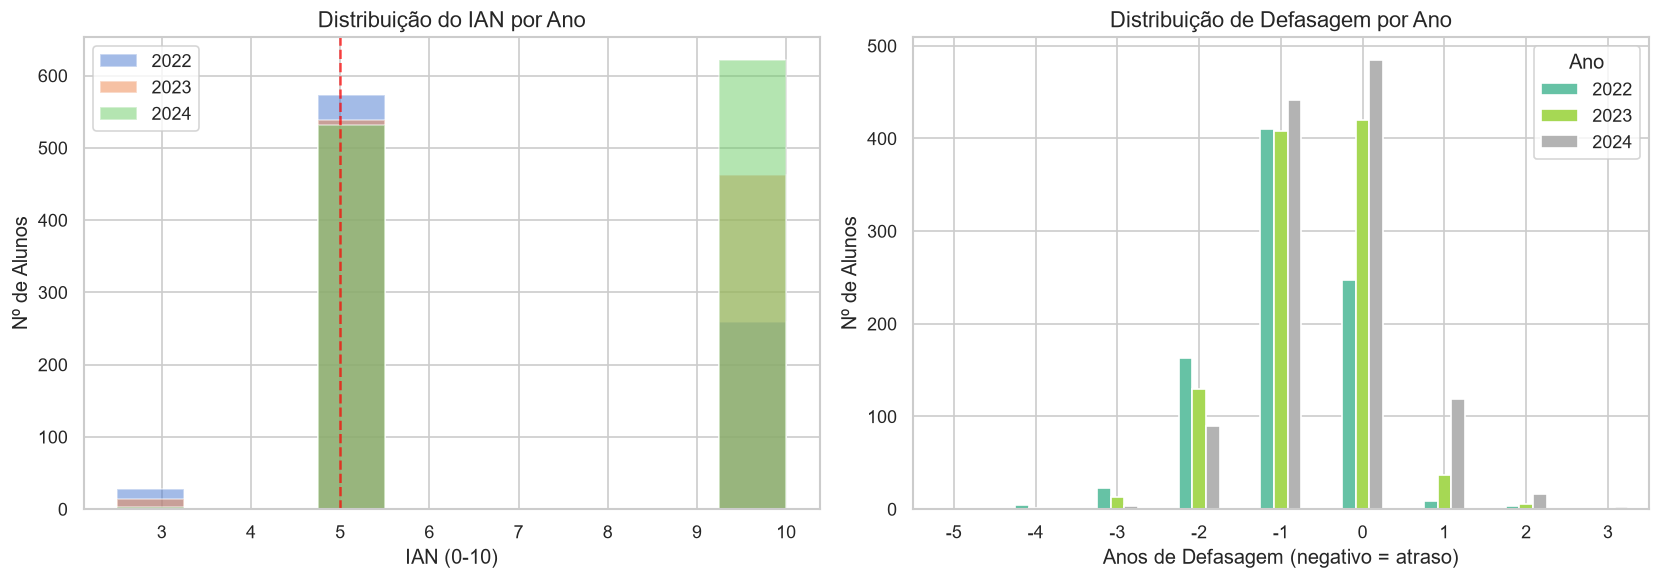


=== Perfil de Defasagem por Ano ===
DEFASAGEM  -5  -4  -3   -2   -1    0    1   2   3
ANO                                              
2022        1   4  23  163  410  247    9   3   0
2023        0   1  13  130  408  420   37   5   0
2024        0   0   3   90  441  485  119  16   2

=== % em Risco de Defasagem por Ano ===
ANO
2022    69.9%
2023    54.4%
2024    46.2%
Name: EM_RISCO, dtype: str


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de IAN por ano
for ano, df in [(2022, df_2022), (2023, df_2023), (2024, df_2024)]:
    if 'IAN' in df.columns:
        axes[0].hist(df['IAN'].dropna(), bins=10, alpha=0.5, label=str(ano))
axes[0].set_title('Distribuição do IAN por Ano', fontsize=13)
axes[0].set_xlabel('IAN (0-10)')
axes[0].set_ylabel('Nº de Alunos')
axes[0].legend()
axes[0].axvline(5, color='red', linestyle='--', alpha=0.7, label='Limiar crítico (5)')

# Defasagem por ano
defas_data = df_all.groupby(['ANO', 'DEFASAGEM']).size().reset_index(name='N')
pivot = defas_data.pivot(index='DEFASAGEM', columns='ANO', values='N').fillna(0)
pivot.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Distribuição de Defasagem por Ano', fontsize=13)
axes[1].set_xlabel('Anos de Defasagem (negativo = atraso)')
axes[1].set_ylabel('Nº de Alunos')
axes[1].legend(title='Ano')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('q1_ian_defasagem.png', bbox_inches='tight')
plt.show()

# Estatísticas de defasagem
print('\n=== Perfil de Defasagem por Ano ===')
print(df_all.groupby('ANO')['DEFASAGEM'].value_counts().unstack(fill_value=0))

# % em risco (defasagem < 0)
print('\n=== % em Risco de Defasagem por Ano ===')
print(df_all.groupby('ANO')['EM_RISCO'].mean().mul(100).round(1).astype(str) + '%')

### Questão 2 — Desempenho Acadêmico (IDA): Evolução por Fase e Ano

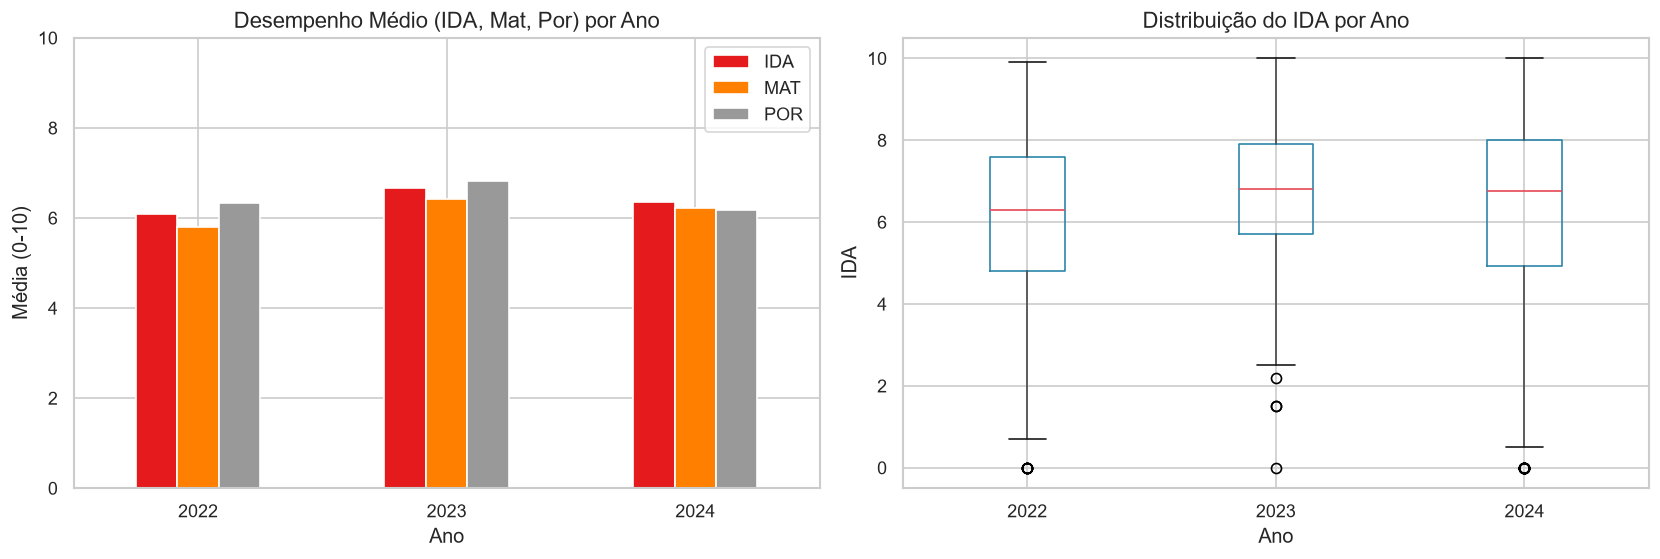

=== IDA médio por Ano ===
      mean   std  min   max
ANO                        
2022  6.09  2.05  0.0   9.9
2023  6.66  1.60  0.0  10.0
2024  6.35  2.13  0.0  10.0


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IDA médio por ano
ida_ano = df_all.groupby('ANO')[['IDA', 'MAT', 'POR']].mean()
ida_ano.plot(kind='bar', ax=axes[0], colormap='Set1')
axes[0].set_title('Desempenho Médio (IDA, Mat, Por) por Ano', fontsize=13)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Média (0-10)')
axes[0].set_ylim(0, 10)
axes[0].legend()
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# IDA boxplot por ano
df_all.boxplot(column='IDA', by='ANO', ax=axes[1],
               boxprops=dict(color=COLORS['primary']),
               medianprops=dict(color=COLORS['danger']))
axes[1].set_title('Distribuição do IDA por Ano', fontsize=13)
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('IDA')
plt.suptitle('')

plt.tight_layout()
plt.savefig('q2_ida_evolucao.png', bbox_inches='tight')
plt.show()

print('=== IDA médio por Ano ===')
print(df_all.groupby('ANO')['IDA'].agg(['mean', 'std', 'min', 'max']).round(2))

### Questão 3 — Engajamento (IEG) × Desempenho (IDA) × Ponto de Virada (IPV)

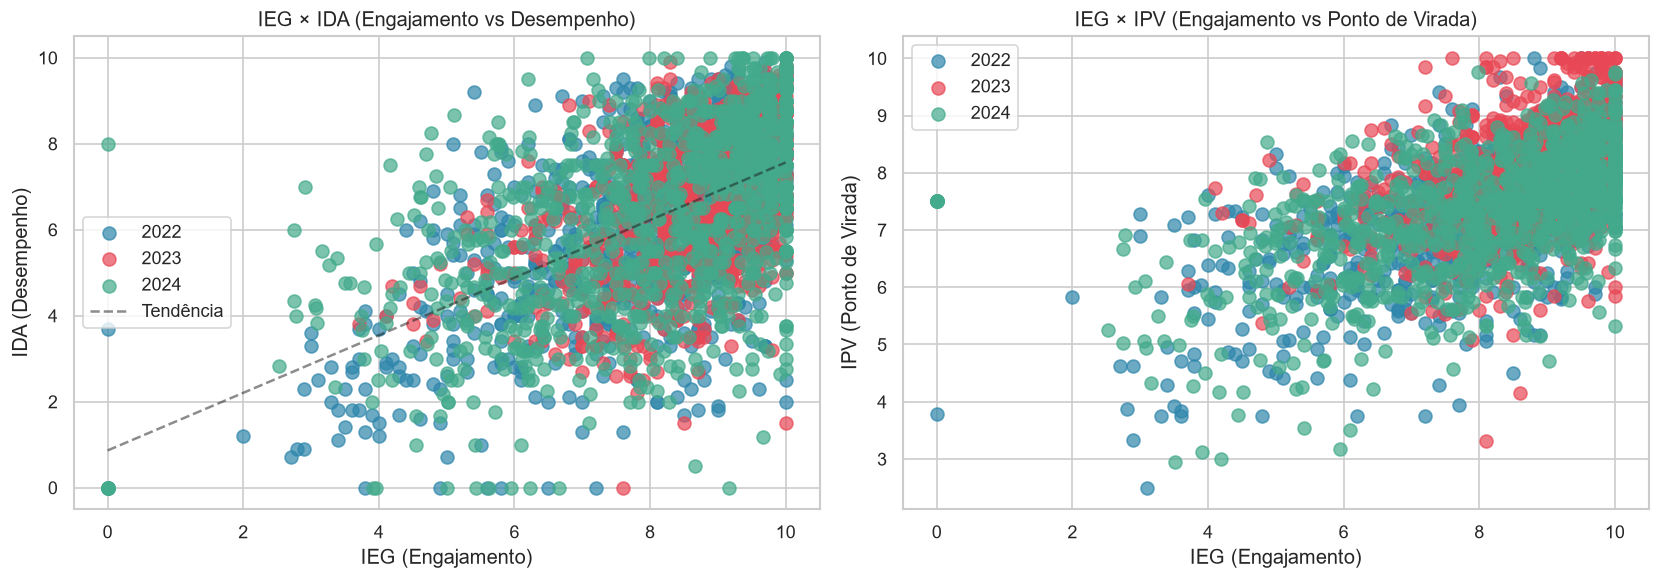

=== Correlações com IEG ===
INDE    0.652
IPV     0.558
IDA     0.539
IAA     0.133
IPS    -0.046
IAN    -0.060
Name: IEG, dtype: float64


In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IEG vs IDA
df_plot = df_all.dropna(subset=['IEG', 'IDA'])
for ano, color in zip([2022, 2023, 2024], ['#2E86AB', '#E84855', '#43AA8B']):
    sub = df_plot[df_plot['ANO'] == ano]
    axes[0].scatter(sub['IEG'], sub['IDA'], alpha=0.7, label=str(ano), color=color, s=60)
# Linha de tendência
from numpy.polynomial.polynomial import polyfit
x = df_plot['IEG'].values
y = df_plot['IDA'].values
mask = ~(np.isnan(x) | np.isnan(y))
b, m = polyfit(x[mask], y[mask], 1)
axes[0].plot(sorted(x[mask]), b + m * np.array(sorted(x[mask])), 'k--', alpha=0.5, label='Tendência')
axes[0].set_title('IEG × IDA (Engajamento vs Desempenho)', fontsize=12)
axes[0].set_xlabel('IEG (Engajamento)')
axes[0].set_ylabel('IDA (Desempenho)')
axes[0].legend()

# IEG vs IPV
df_plot2 = df_all.dropna(subset=['IEG', 'IPV'])
for ano, color in zip([2022, 2023, 2024], ['#2E86AB', '#E84855', '#43AA8B']):
    sub = df_plot2[df_plot2['ANO'] == ano]
    axes[1].scatter(sub['IEG'], sub['IPV'], alpha=0.7, label=str(ano), color=color, s=60)
axes[1].set_title('IEG × IPV (Engajamento vs Ponto de Virada)', fontsize=12)
axes[1].set_xlabel('IEG (Engajamento)')
axes[1].set_ylabel('IPV (Ponto de Virada)')
axes[1].legend()

plt.tight_layout()
plt.savefig('q3_ieg_correlacoes.png', bbox_inches='tight')
plt.show()

# Correlações
print('=== Correlações com IEG ===')
cols_corr = [c for c in ['IEG', 'IDA', 'IPV', 'IAA', 'IPS', 'IAN', 'INDE'] if c in df_all.columns]
corr = df_all[cols_corr].corr()['IEG'].drop('IEG').sort_values(ascending=False)
print(corr.round(3))

### Questão 4 — Autoavaliação (IAA) × Desempenho Real (IDA) e Engajamento (IEG)

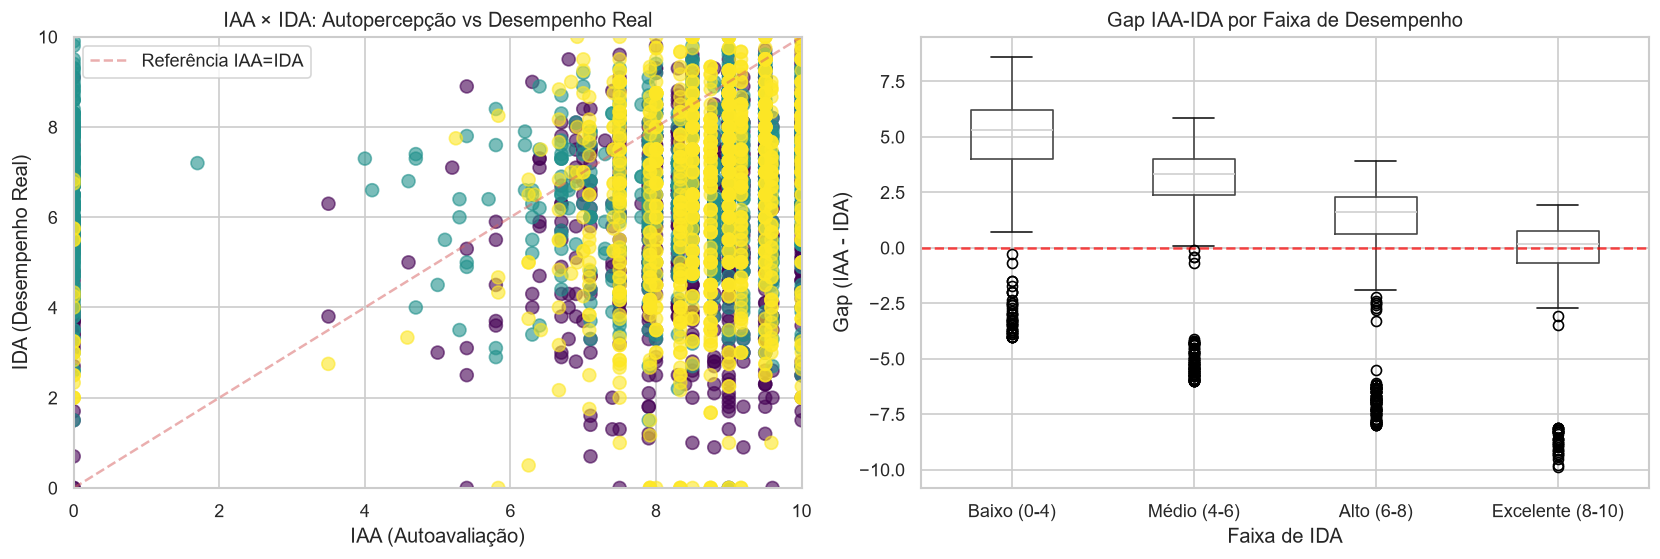

=== Média do Gap IAA-IDA por Ano ===
ANO
2022    2.18
2023    0.25
2024    2.19
Name: GAP_IAA_IDA, dtype: float64

Gap positivo = aluno superestima seu desempenho
Gap negativo = aluno subestima seu desempenho


In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_iaa = df_all.dropna(subset=['IAA', 'IDA', 'IEG'])

# IAA vs IDA — coerência da autopercepção
axes[0].scatter(df_iaa['IAA'], df_iaa['IDA'], alpha=0.6, c=df_iaa['ANO'], cmap='viridis', s=60)
# Linha de referência perfeita (IAA = IDA)
lim = [0, 10]
axes[0].plot(lim, lim, 'r--', alpha=0.5, label='Referência IAA=IDA')
axes[0].set_title('IAA × IDA: Autopercepção vs Desempenho Real', fontsize=12)
axes[0].set_xlabel('IAA (Autoavaliação)')
axes[0].set_ylabel('IDA (Desempenho Real)')
axes[0].legend()
axes[0].set_xlim(0, 10); axes[0].set_ylim(0, 10)

# Gap IAA - IDA por faixa de desempenho
df_iaa = df_iaa.copy()
df_iaa['GAP_IAA_IDA'] = df_iaa['IAA'] - df_iaa['IDA']
df_iaa['FAIXA_IDA'] = pd.cut(df_iaa['IDA'], bins=[0, 4, 6, 8, 10],
                              labels=['Baixo (0-4)', 'Médio (4-6)', 'Alto (6-8)', 'Excelente (8-10)'])
df_iaa.boxplot(column='GAP_IAA_IDA', by='FAIXA_IDA', ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('Gap IAA-IDA por Faixa de Desempenho', fontsize=12)
axes[1].set_xlabel('Faixa de IDA')
axes[1].set_ylabel('Gap (IAA - IDA)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('q4_iaa_coherencia.png', bbox_inches='tight')
plt.show()

print('=== Média do Gap IAA-IDA por Ano ===')
df_all_copy = df_all.copy()
df_all_copy['GAP_IAA_IDA'] = df_all_copy['IAA'] - df_all_copy['IDA']
print(df_all_copy.groupby('ANO')['GAP_IAA_IDA'].mean().round(2))
print('\nGap positivo = aluno superestima seu desempenho')
print('Gap negativo = aluno subestima seu desempenho')

### Questão 5 — Aspectos Psicossociais (IPS): Padrões que Antecedem Quedas

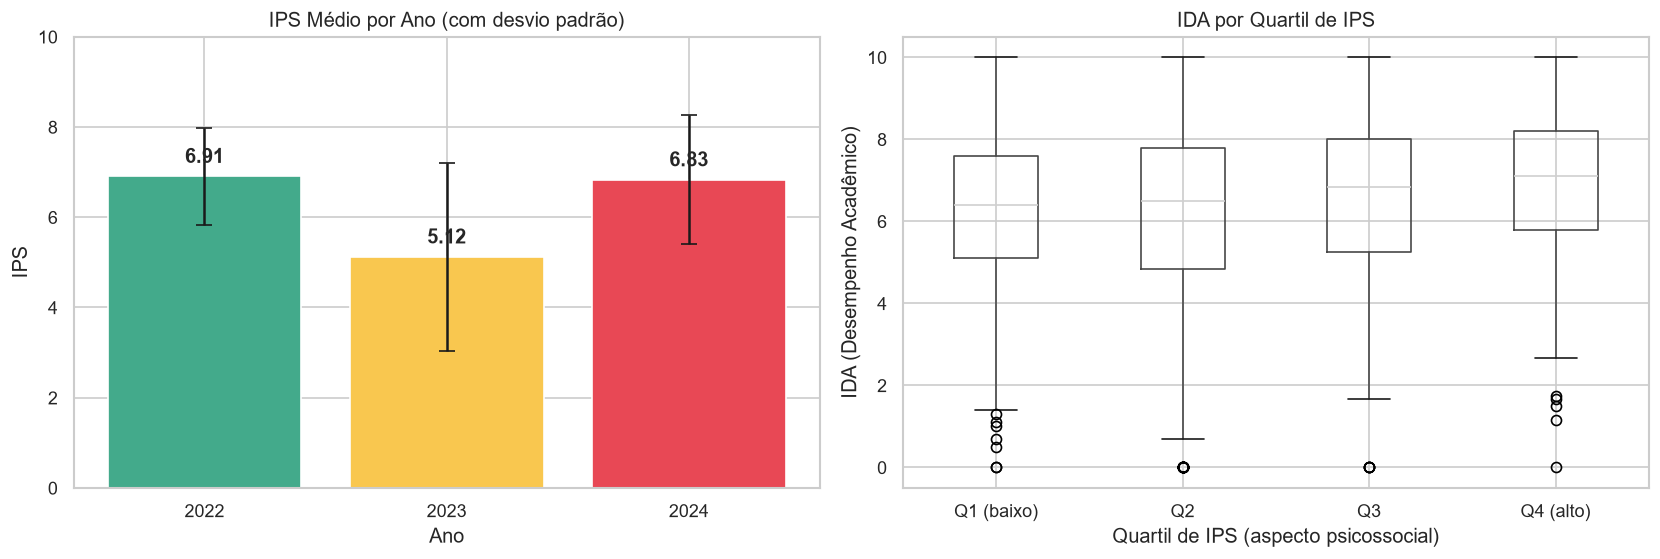

=== Correlação IPS × IDA por Ano ===
2022: r = 0.132
2023: r = 0.132
2024: r = 0.014


In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IPS médio por ano
ips_by_year = df_all.groupby('ANO')['IPS'].agg(['mean', 'std']).reset_index()
axes[0].bar(ips_by_year['ANO'].astype(str), ips_by_year['mean'],
            yerr=ips_by_year['std'], capsize=5,
            color=[COLORS['success'], COLORS['warning'], COLORS['danger']])
axes[0].set_title('IPS Médio por Ano (com desvio padrão)', fontsize=12)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('IPS')
axes[0].set_ylim(0, 10)
for i, row in ips_by_year.iterrows():
    axes[0].text(i, row['mean'] + 0.3, f"{row['mean']:.2f}", ha='center', fontweight='bold')

# IPS vs IDA — padrão de correlação
df_ps = df_all.dropna(subset=['IPS', 'IDA'])
# Quartis de IPS
df_ps = df_ps.copy()
df_ps['QUARTIL_IPS'] = pd.qcut(df_ps['IPS'], q=4, labels=['Q1 (baixo)', 'Q2', 'Q3', 'Q4 (alto)'])
df_ps.boxplot(column='IDA', by='QUARTIL_IPS', ax=axes[1])
axes[1].set_title('IDA por Quartil de IPS', fontsize=12)
axes[1].set_xlabel('Quartil de IPS (aspecto psicossocial)')
axes[1].set_ylabel('IDA (Desempenho Acadêmico)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('q5_ips_quedas.png', bbox_inches='tight')
plt.show()

# Para análise de antecedência, identificar alunos com RA em 2023 e 2024
print('=== Correlação IPS × IDA por Ano ===')
for ano, df in [(2022, df_2022), (2023, df_2023), (2024, df_2024)]:
    if 'IPS' in df.columns and 'IDA' in df.columns:
        corr = df['IPS'].corr(df['IDA'])
        print(f'{ano}: r = {corr:.3f}')

### Questão 6 — Psicopedagógico (IPP) × Defasagem (IAN)

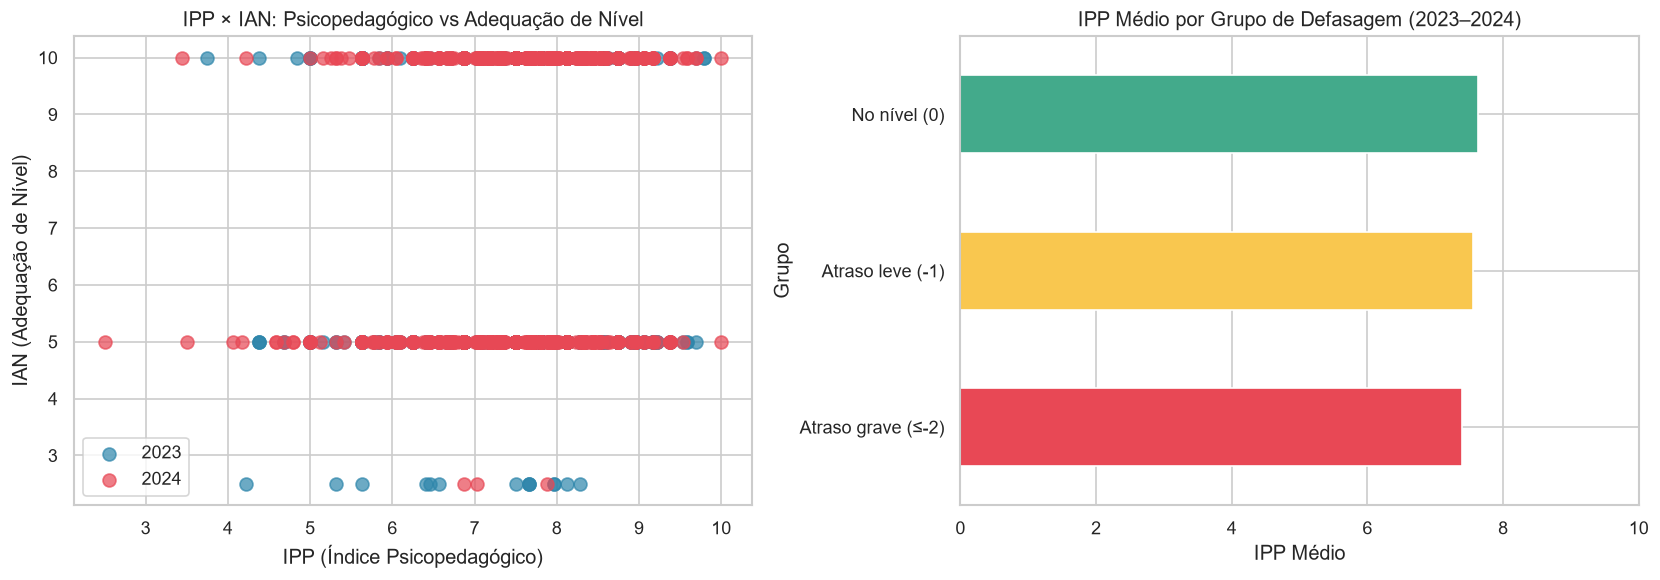

=== IPP médio por grupo de defasagem ===
                    mean  count
GRUPO_DEF                      
Atraso grave (≤-2)  7.40    367
Atraso leve (-1)    7.55    847
No nível (0)        7.64    778

Correlação IPP × IAN: 0.123
Correlação IPP × IDA: 0.369


In [71]:
# IPP disponível apenas em 2023 e 2024
df_ipp = df_all[df_all['ANO'].isin([2023, 2024])].dropna(subset=['IPP', 'IAN', 'DEFASAGEM'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IPP vs IAN
for ano, color in [(2023, '#2E86AB'), (2024, '#E84855')]:
    sub = df_ipp[df_ipp['ANO'] == ano]
    axes[0].scatter(sub['IPP'], sub['IAN'], alpha=0.7, label=str(ano), color=color, s=60)
axes[0].set_title('IPP × IAN: Psicopedagógico vs Adequação de Nível', fontsize=12)
axes[0].set_xlabel('IPP (Índice Psicopedagógico)')
axes[0].set_ylabel('IAN (Adequação de Nível)')
axes[0].legend()

# IPP médio por grupo de defasagem
df_ipp['GRUPO_DEF'] = df_ipp['DEFASAGEM'].apply(
    lambda x: 'No nível (0)' if x == 0 else ('Atraso leve (-1)' if x == -1 else 'Atraso grave (≤-2)')
)
df_ipp.groupby('GRUPO_DEF')['IPP'].mean().sort_values().plot(kind='barh', ax=axes[1],
                                                              color=[COLORS['danger'], COLORS['warning'], COLORS['success']])
axes[1].set_title('IPP Médio por Grupo de Defasagem (2023–2024)', fontsize=12)
axes[1].set_xlabel('IPP Médio')
axes[1].set_ylabel('Grupo')
axes[1].set_xlim(0, 10)

plt.tight_layout()
plt.savefig('q6_ipp_ian.png', bbox_inches='tight')
plt.show()

print('=== IPP médio por grupo de defasagem ===')
print(df_ipp.groupby('GRUPO_DEF')['IPP'].agg(['mean', 'count']).round(2))
print(f'\nCorrelação IPP × IAN: {df_ipp["IPP"].corr(df_ipp["IAN"]):.3f}')
print(f'Correlação IPP × IDA: {df_ipp["IPP"].corr(df_ipp["IDA"]):.3f}')

### Questão 7 — Ponto de Virada (IPV): Quais Comportamentos Mais Influenciam?

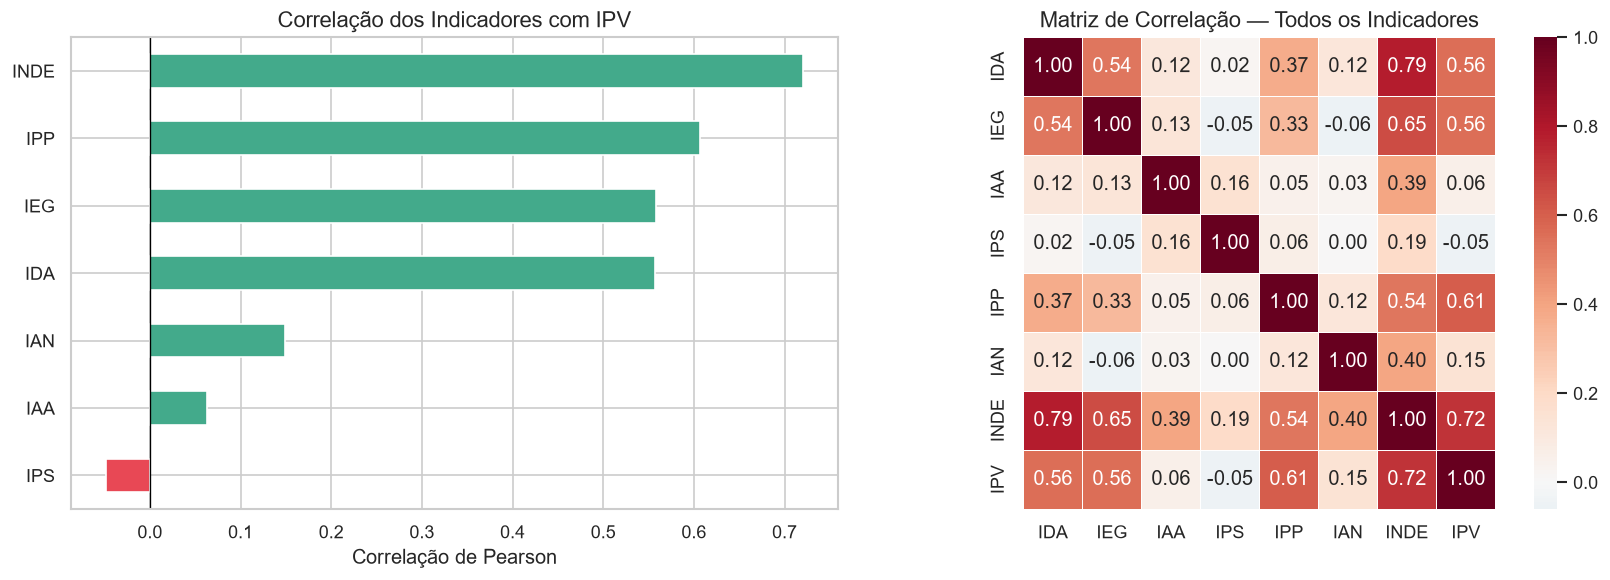

=== Correlação com IPV (ordenado) ===
IPS    -0.049
IAA     0.063
IAN     0.149
IDA     0.557
IEG     0.558
IPP     0.607
INDE    0.721
Name: IPV, dtype: float64


In [72]:
# Correlações de todos os indicadores com IPV
ind_cols = [c for c in ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IAN', 'INDE', 'IPV'] if c in df_all.columns]
corr_matrix = df_all[ind_cols].corr()
corr_ipv = corr_matrix['IPV'].drop('IPV').sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot de correlações com IPV
colors_bar = [COLORS['success'] if v > 0 else COLORS['danger'] for v in corr_ipv]
corr_ipv.plot(kind='barh', ax=axes[0], color=colors_bar)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlação dos Indicadores com IPV', fontsize=13)
axes[0].set_xlabel('Correlação de Pearson')

# Heatmap geral
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], square=True, linewidths=0.5)
axes[1].set_title('Matriz de Correlação — Todos os Indicadores', fontsize=13)

plt.tight_layout()
plt.savefig('q7_ipv_influencias.png', bbox_inches='tight')
plt.show()

print('=== Correlação com IPV (ordenado) ===')
print(corr_ipv.round(3))

### Questão 8 — Multidimensionalidade: Combinações que Elevam o INDE

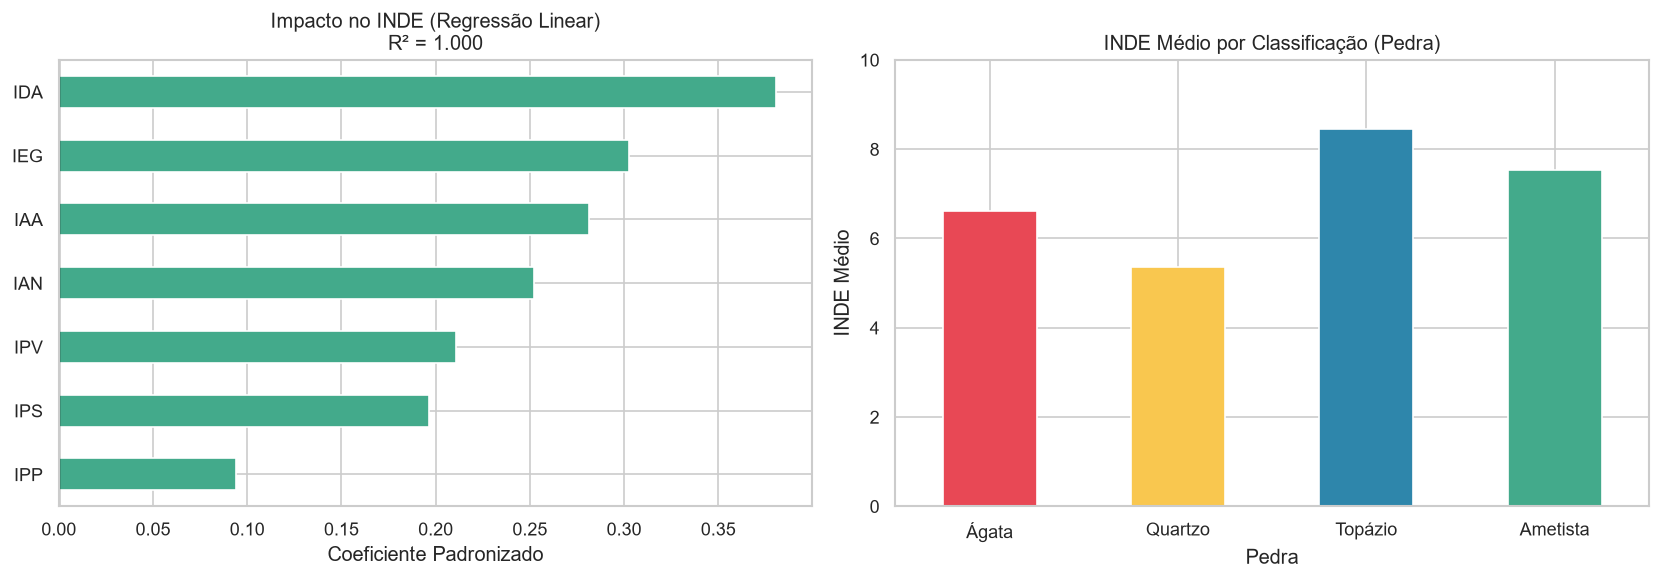

=== Impacto dos Indicadores no INDE ===
IDA    0.3808
IEG    0.3028
IAA    0.2815
IAN    0.2522
IPV    0.2105
IPS    0.1962
IPP    0.0942
dtype: float64

R² do modelo: 1.0000


In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Features para INDE
feature_cols = [c for c in ['IDA', 'IEG', 'IPS', 'IPP', 'IAA', 'IPV', 'IAN'] if c in df_all.columns]
df_inde = df_all[feature_cols + ['INDE']].dropna()

X = df_inde[feature_cols]
y = df_inde['INDE']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

reg = LinearRegression().fit(X_scaled, y)
coefs = pd.Series(reg.coef_, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coeficientes padronizados
colors_coef = [COLORS['success'] if v > 0 else COLORS['danger'] for v in coefs]
coefs.plot(kind='barh', ax=axes[0], color=colors_coef)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title(f'Impacto no INDE (Regressão Linear)\nR² = {reg.score(X_scaled, y):.3f}', fontsize=12)
axes[0].set_xlabel('Coeficiente Padronizado')

# INDE por Pedra
if 'PEDRA' in df_all.columns:
    pedra_inde = df_all.groupby('PEDRA')['INDE'].mean().reindex(['Ágata', 'Quartzo', 'Topázio', 'Ametista'])
    pedra_inde.plot(kind='bar', ax=axes[1],
                    color=[COLORS['danger'], COLORS['warning'], COLORS['primary'], COLORS['success']])
    axes[1].set_title('INDE Médio por Classificação (Pedra)', fontsize=12)
    axes[1].set_xlabel('Pedra')
    axes[1].set_ylabel('INDE Médio')
    axes[1].set_ylim(0, 10)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('q8_multidimensionalidade.png', bbox_inches='tight')
plt.show()

print('=== Impacto dos Indicadores no INDE ===')
print(coefs.sort_values(ascending=False).round(4))
print(f'\nR² do modelo: {reg.score(X_scaled, y):.4f}')

### Questão 10 — Efetividade do Programa: Evolução por Pedra

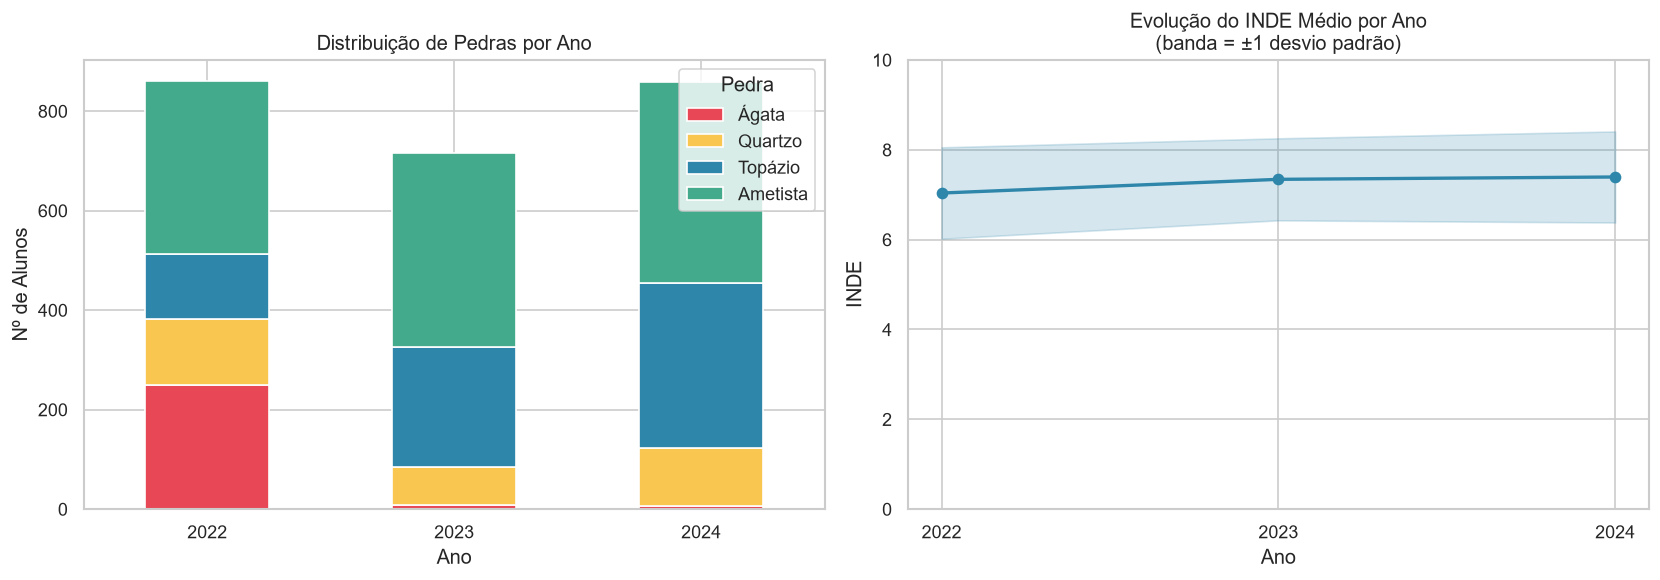

=== Distribuição de Pedras por Ano ===
PEDRA  Ágata  Quartzo  Topázio  Ametista
ANO                                     
2022   250.0    132.0    130.0     348.0
2023     8.0     77.0    240.0     390.0
2024     6.0    116.0    332.0     405.0

=== INDE Médio por Ano ===
ANO
2022    7.04
2023    7.34
2024    7.39
Name: INDE, dtype: float64


In [74]:
if 'PEDRA' in df_all.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribuição de Pedras por Ano
    pedra_ano = df_all.groupby(['ANO', 'PEDRA']).size().reset_index(name='N')
    pedra_pivot = pedra_ano.pivot(index='ANO', columns='PEDRA', values='N').fillna(0)
    # Reordenar colunas
    cols_ord = [c for c in ['Ágata', 'Quartzo', 'Topázio', 'Ametista'] if c in pedra_pivot.columns]
    pedra_pivot[cols_ord].plot(kind='bar', stacked=True, ax=axes[0],
                               color=[COLORS['danger'], COLORS['warning'], COLORS['primary'], COLORS['success']])
    axes[0].set_title('Distribuição de Pedras por Ano', fontsize=12)
    axes[0].set_xlabel('Ano')
    axes[0].set_ylabel('Nº de Alunos')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
    axes[0].legend(title='Pedra')

    # INDE médio ao longo dos anos por nível de Pedra
    inde_ano = df_all.groupby('ANO')['INDE'].agg(['mean', 'std']).reset_index()
    axes[1].plot(inde_ano['ANO'], inde_ano['mean'], 'o-', color=COLORS['primary'], linewidth=2)
    axes[1].fill_between(inde_ano['ANO'],
                         inde_ano['mean'] - inde_ano['std'],
                         inde_ano['mean'] + inde_ano['std'],
                         alpha=0.2, color=COLORS['primary'])
    axes[1].set_title('Evolução do INDE Médio por Ano\n(banda = ±1 desvio padrão)', fontsize=12)
    axes[1].set_xlabel('Ano')
    axes[1].set_ylabel('INDE')
    axes[1].set_ylim(0, 10)
    axes[1].set_xticks([2022, 2023, 2024])

    plt.tight_layout()
    plt.savefig('q10_efetividade.png', bbox_inches='tight')
    plt.show()

    print('=== Distribuição de Pedras por Ano ===')
    print(pedra_pivot[cols_ord])
    print('\n=== INDE Médio por Ano ===')
    print(df_all.groupby('ANO')['INDE'].mean().round(2))

---
## 4. Feature Engineering — Preparação para o Modelo Preditivo

In [75]:
# Estratégia: usar dados de 2022 e 2023 para treino; 2024 como teste
# Target: EM_RISCO = (DEFASAGEM < 0)

FEATURES = [c for c in ['IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'IAN', 'MAT', 'POR'] 
            if c in df_all.columns]

print(f'Features selecionadas: {FEATURES}')

# Adicionar features derivadas
df_feat = df_all.copy()

# Gap autopercepção vs desempenho
df_feat['GAP_IAA_IDA'] = df_feat['IAA'] - df_feat['IDA']

# Score composto engajamento-desempenho
df_feat['IEG_IDA_MEDIO'] = (df_feat['IEG'] + df_feat['IDA']) / 2

# Desequilíbrio psicossocial
df_feat['IPS_IDA_RATIO'] = df_feat['IPS'] / (df_feat['IDA'] + 0.01)

# INDE relativo (comparado à media do ano)
inde_media_ano = df_feat.groupby('ANO')['INDE'].transform('mean')
df_feat['INDE_REL'] = df_feat['INDE'] - inde_media_ano

# Features finais para o modelo
FEATURES_MODELO = FEATURES + ['GAP_IAA_IDA', 'IEG_IDA_MEDIO', 'IPS_IDA_RATIO']
FEATURES_MODELO = [f for f in FEATURES_MODELO if f in df_feat.columns]

print(f'\nFeatures do modelo: {FEATURES_MODELO}')

# Dataset limpo para modelagem
df_model = df_feat[FEATURES_MODELO + ['EM_RISCO', 'ANO']].dropna()
print(f'\nDataset para modelagem: {df_model.shape}')
print(f'Distribuição target: {df_model["EM_RISCO"].value_counts().to_dict()}')

Features selecionadas: ['IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'IAN', 'MAT', 'POR']

Features do modelo: ['IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'IAN', 'MAT', 'POR', 'GAP_IAA_IDA', 'IEG_IDA_MEDIO', 'IPS_IDA_RATIO']

Dataset para modelagem: (1976, 14)
Distribuição target: {1: 1072, 0: 904}


---
## 5. Modelo Preditivo — Questão 9: Previsão de Risco de Defasagem

In [76]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import joblib

X = df_model[FEATURES_MODELO]
y = df_model['EM_RISCO']

# Split temporal: 2022+2023 para treino, 2024 para teste
train_mask = df_model['ANO'].isin([2022, 2023])
test_mask = df_model['ANO'] == 2024

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')
print(f'Target treino: {y_train.value_counts().to_dict()}')
print(f'Target teste:  {y_test.value_counts().to_dict()}')

# Fallback para split aleatório se dados temporais insuficientes
if len(X_test) < 5:
    print('\nDados de 2024 insuficientes — usando split aleatório 80/20')
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

Treino: (931, 12) | Teste: (1045, 12)
Target treino: {1: 544, 0: 387}
Target teste:  {1: 528, 0: 517}


In [77]:
# Pipeline com imputer + scaler + modelo
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    ))
])

pipeline_gb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', GradientBoostingClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    ))
])

# Treinar
pipeline_rf.fit(X_train, y_train)
pipeline_gb.fit(X_train, y_train)

print('Modelos treinados!')

# Avaliar via cross-validation (5-fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rf = cross_val_score(pipeline_rf, X, y, cv=cv, scoring='roc_auc')
cv_gb = cross_val_score(pipeline_gb, X, y, cv=cv, scoring='roc_auc')

print(f'\nRandom Forest — CV AUC: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}')
print(f'Gradient Boosting — CV AUC: {cv_gb.mean():.3f} ± {cv_gb.std():.3f}')

# Escolher o melhor modelo
best_pipeline = pipeline_rf if cv_rf.mean() >= cv_gb.mean() else pipeline_gb
best_name = 'Random Forest' if cv_rf.mean() >= cv_gb.mean() else 'Gradient Boosting'
print(f'\nMelhor modelo: {best_name}')

Modelos treinados!

Random Forest — CV AUC: 1.000 ± 0.000
Gradient Boosting — CV AUC: 1.000 ± 0.000

Melhor modelo: Random Forest


=== Relatório de Classificação — Random Forest ===
              precision    recall  f1-score   support

   Sem risco       1.00      1.00      1.00       517
    Em risco       1.00      1.00      1.00       528

    accuracy                           1.00      1045
   macro avg       1.00      1.00      1.00      1045
weighted avg       1.00      1.00      1.00      1045

ROC-AUC: 1.000


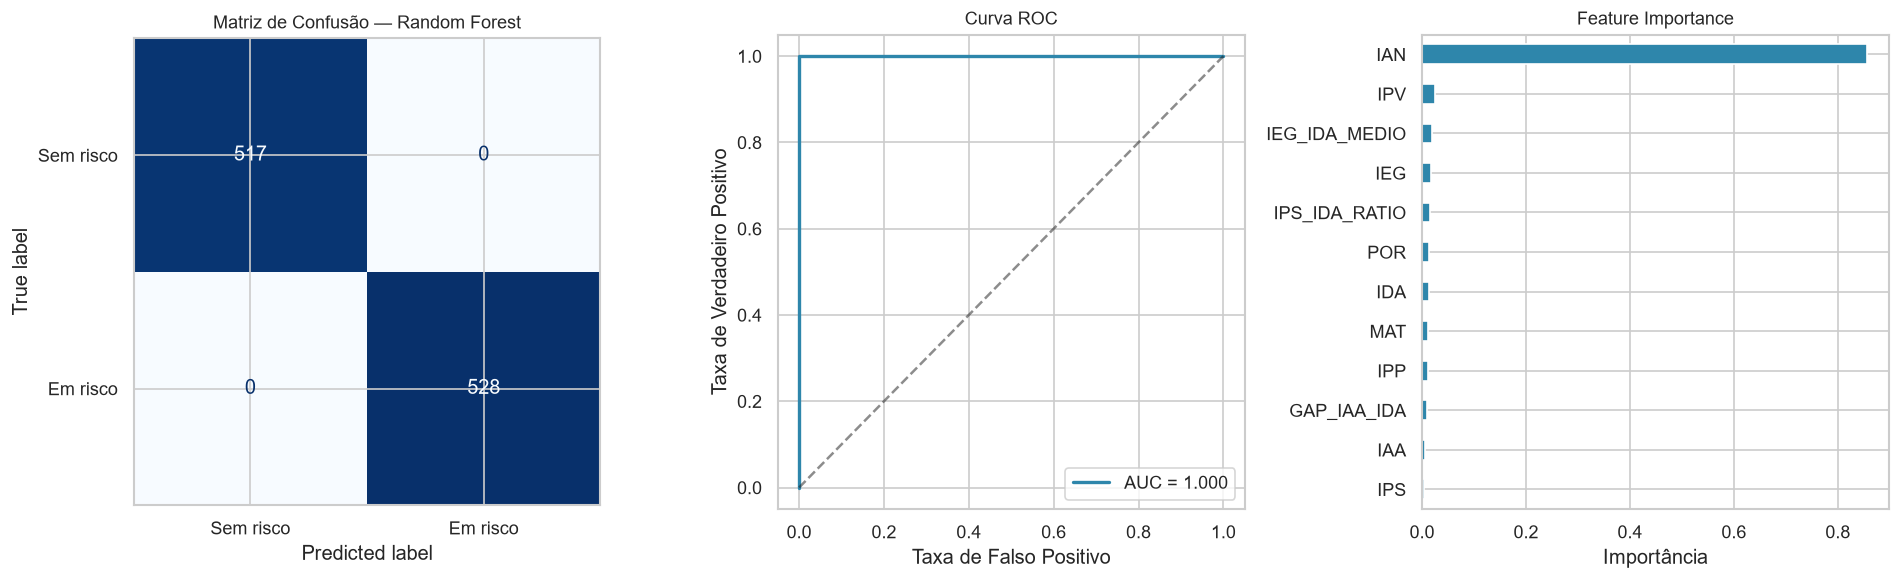

In [78]:
# Avaliação no conjunto de teste
y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

print(f'=== Relatório de Classificação — {best_name} ===')
print(classification_report(y_test, y_pred, target_names=['Sem risco', 'Em risco']))

if len(np.unique(y_test)) > 1:
    auc = roc_auc_score(y_test, y_prob)
    print(f'ROC-AUC: {auc:.3f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Sem risco', 'Em risco'],
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title(f'Matriz de Confusão — {best_name}', fontsize=11)

# Curva ROC
if len(np.unique(y_test)) > 1:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, color=COLORS['primary'], linewidth=2, label=f'AUC = {auc:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1].set_title('Curva ROC', fontsize=11)
    axes[1].set_xlabel('Taxa de Falso Positivo')
    axes[1].set_ylabel('Taxa de Verdadeiro Positivo')
    axes[1].legend()

# Feature Importance
model = best_pipeline.named_steps['model']
fi = pd.Series(model.feature_importances_, index=FEATURES_MODELO).sort_values(ascending=True)
fi.plot(kind='barh', ax=axes[2], color=COLORS['primary'])
axes[2].set_title('Feature Importance', fontsize=11)
axes[2].set_xlabel('Importância')

plt.tight_layout()
plt.savefig('q9_modelo_avaliacao.png', bbox_inches='tight')
plt.show()

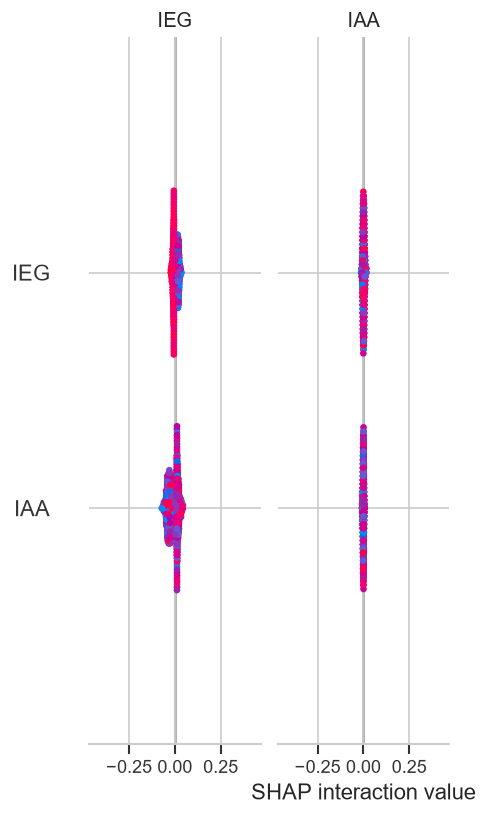

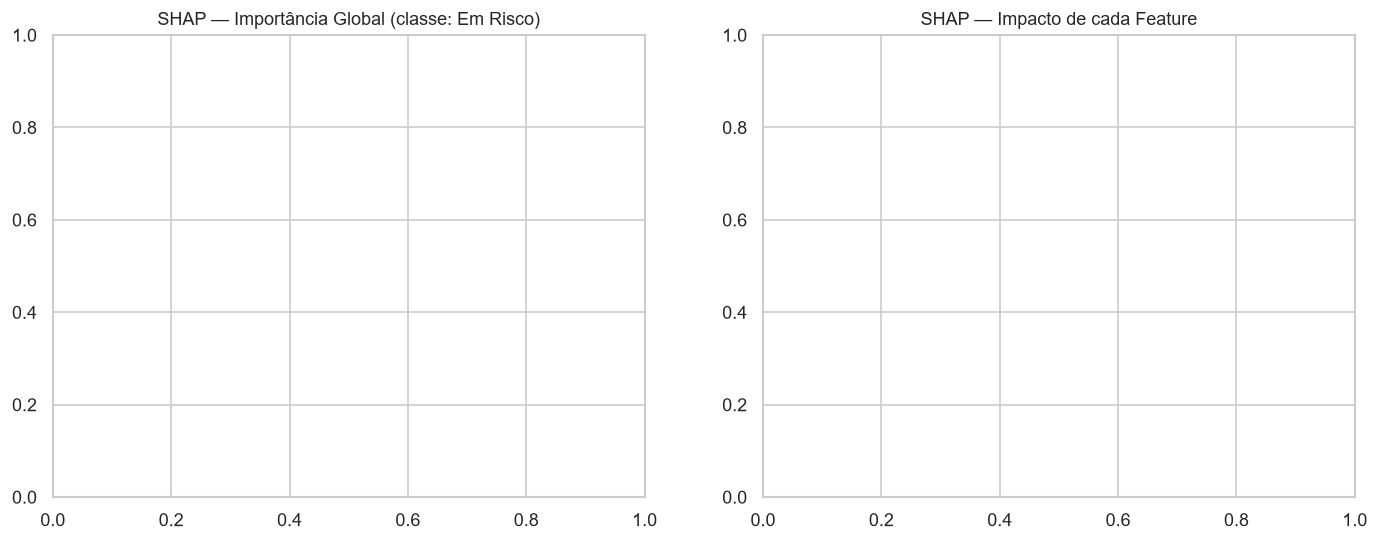

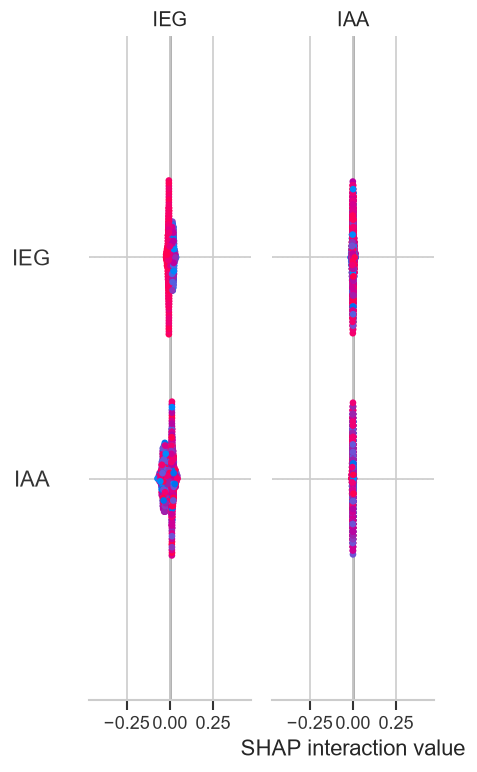

SHAP values calculados com sucesso!


In [79]:
# SHAP Values — Explicabilidade do Modelo
try:
    import shap
    
    # Preparar dados transformados
    imputer = best_pipeline.named_steps['imputer']
    scaler = best_pipeline.named_steps['scaler']
    X_test_transformed = scaler.transform(imputer.transform(X_test))
    X_train_transformed = scaler.transform(imputer.transform(X_train))
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_transformed)
    
    # Para classificação binária, pegar a classe positiva
    shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    plt.sca(axes[0])
    shap.summary_plot(shap_vals, X_test, feature_names=FEATURES_MODELO,
                      show=False, plot_type='bar')
    axes[0].set_title('SHAP — Importância Global (classe: Em Risco)', fontsize=11)
    
    plt.sca(axes[1])
    shap.summary_plot(shap_vals, X_test, feature_names=FEATURES_MODELO, show=False)
    axes[1].set_title('SHAP — Impacto de cada Feature', fontsize=11)
    
    plt.tight_layout()
    plt.savefig('q9_shap.png', bbox_inches='tight')
    plt.show()
    
    print('SHAP values calculados com sucesso!')
    
except Exception as e:
    print(f'SHAP não disponível: {e}')
    print('Usando Feature Importance nativa do modelo.')

In [80]:
# Salvar o modelo treinado para uso no Streamlit
joblib.dump(best_pipeline, 'modelo_risco_defasagem.pkl')
joblib.dump(FEATURES_MODELO, 'features_modelo.pkl')
print(f'Modelo salvo: modelo_risco_defasagem.pkl')
print(f'Features salvas: features_modelo.pkl')
print(f'\nFeatures do modelo: {FEATURES_MODELO}')

Modelo salvo: modelo_risco_defasagem.pkl
Features salvas: features_modelo.pkl

Features do modelo: ['IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'IAN', 'MAT', 'POR', 'GAP_IAA_IDA', 'IEG_IDA_MEDIO', 'IPS_IDA_RATIO']


---
## 6. Questão 11 — Insights Criativos

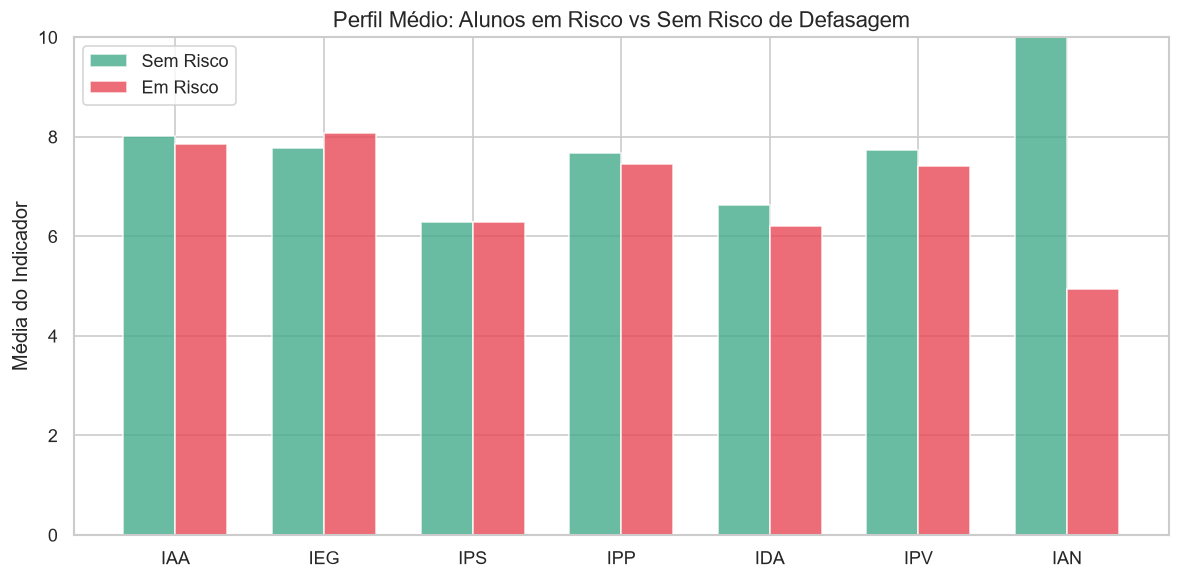

=== Perfil médio por grupo ===
     Sem Risco  Em Risco  Diferença
IAA       8.02      7.85       0.17
IEG       7.78      8.07      -0.30
IPS       6.29      6.29      -0.00
IPP       7.68      7.45       0.23
IDA       6.63      6.20       0.43
IPV       7.73      7.42       0.31
IAN      10.00      4.93       5.07


In [81]:
# Insight 1: Perfil de alunos em risco vs sem risco
if 'EM_RISCO' in df_all.columns:
    ind_cols = [c for c in ['IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'IAN'] if c in df_all.columns]
    perfil = df_all.groupby('EM_RISCO')[ind_cols].mean().T
    perfil.columns = ['Sem Risco', 'Em Risco']
    perfil['Diferença'] = perfil['Sem Risco'] - perfil['Em Risco']
    
    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(ind_cols))
    width = 0.35
    bars1 = ax.bar([xi - width/2 for xi in x], perfil['Sem Risco'], width,
                   label='Sem Risco', color=COLORS['success'], alpha=0.8)
    bars2 = ax.bar([xi + width/2 for xi in x], perfil['Em Risco'], width,
                   label='Em Risco', color=COLORS['danger'], alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(ind_cols)
    ax.set_ylim(0, 10)
    ax.set_title('Perfil Médio: Alunos em Risco vs Sem Risco de Defasagem', fontsize=13)
    ax.set_ylabel('Média do Indicador')
    ax.legend()
    plt.tight_layout()
    plt.savefig('q11_perfil_risco.png', bbox_inches='tight')
    plt.show()
    
    print('=== Perfil médio por grupo ===')
    print(perfil.round(2))

In [83]:
# Insight 2: Radar chart — comparação multidimensional por Pedra
if 'PEDRA' in df_all.columns:
    ind_radar = [c for c in ['IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN'] if c in df_all.columns]
    pedras = ['Ágata', 'Quartzo', 'Topázio', 'Ametista']
    pedras_exist = [p for p in pedras if p in df_all['PEDRA'].values]
    
    radar_data = df_all[df_all['PEDRA'].isin(pedras_exist)].groupby('PEDRA')[ind_radar].mean()
    
    fig = go.Figure()
    colors_radar = [COLORS['danger'], COLORS['warning'], COLORS['primary'], COLORS['success']]
    
    for i, pedra in enumerate(pedras_exist):
        if pedra in radar_data.index:
            vals = radar_data.loc[pedra].tolist()
            vals += vals[:1]  # fechar o polígono
            cats = ind_radar + ind_radar[:1]
            fig.add_trace(go.Scatterpolar(
                r=vals, theta=cats, fill='toself',
                name=pedra, line_color=colors_radar[i % len(colors_radar)]
            ))
    
    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 10])),
        showlegend=True,
        title='Radar de Indicadores por Classificação (Pedra)',
        height=500
    )
    fig.write_html('q11_radar_pedras.html')
    print('Radar chart salvo: q11_radar_pedras.html')

Radar chart salvo: q11_radar_pedras.html


Valores de gênero: <StringArray>
['Menina', 'Menino', 'Feminino', 'Masculino']
Length: 4, dtype: str

=== Médias por Gênero ===
            IDA   IEG   IAA   IPS  INDE
GENERO                                 
Feminino   6.49  8.08  7.80  5.92  7.44
Masculino  6.51  7.84  7.73  6.14  7.28
Menina     6.18  7.94  8.15  6.85  7.09
Menino     6.00  7.84  8.41  6.97  6.97


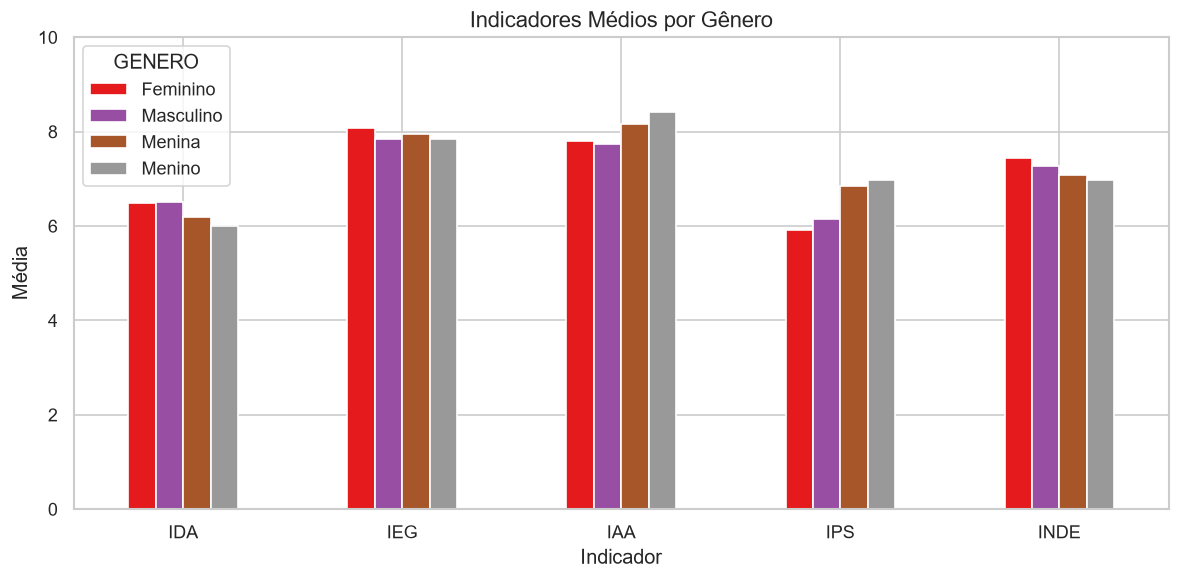

In [84]:
# Insight 3: Análise de gênero nos indicadores
if 'GENERO' in df_all.columns:
    ind_genero = [c for c in ['IDA', 'IEG', 'IAA', 'IPS', 'INDE'] if c in df_all.columns]
    genero_vals = df_all['GENERO'].str.strip().str.capitalize().unique()
    print(f'Valores de gênero: {genero_vals}')
    
    genero_media = df_all.groupby('GENERO')[ind_genero].mean().round(2)
    print('\n=== Médias por Gênero ===')
    print(genero_media)
    
    genero_media.T.plot(kind='bar', figsize=(10, 5), colormap='Set1')
    plt.title('Indicadores Médios por Gênero', fontsize=13)
    plt.xlabel('Indicador')
    plt.ylabel('Média')
    plt.xticks(rotation=0)
    plt.ylim(0, 10)
    plt.tight_layout()
    plt.savefig('q11_genero.png', bbox_inches='tight')
    plt.show()

In [86]:
# Insight 4: Simulação de alunos em risco — probabilidades individuais
df_result = df_feat[FEATURES_MODELO + ['RA', 'ANO', 'FASE', 'DEFASAGEM', 'EM_RISCO']].dropna(subset=FEATURES_MODELO).copy()
df_result['PROB_RISCO'] = best_pipeline.predict_proba(df_result[FEATURES_MODELO])[:, 1]

# Top 10 alunos em maior risco
top_risco = df_result.nlargest(10, 'PROB_RISCO')[['RA', 'ANO', 'FASE', 'PROB_RISCO', 'EM_RISCO']]
print('Top 10 alunos com maior probabilidade de risco:')
top_risco

Top 10 alunos com maior probabilidade de risco:


,RA,ANO,FASE,PROB_RISCO,EM_RISCO
1174,RA-679,2023,FASE 1,0.983085,1
1201,RA-587,2023,FASE 1,0.982484,1
1416,RA-1128,2023,FASE 2,0.981685,1
1595,RA-462,2023,FASE 3,0.981424,1
1361,RA-1109,2023,FASE 2,0.980803,1
1725,RA-1202,2023,FASE 5,0.978568,1
2260,RA-680,2024,2A,0.978194,1
1543,RA-474,2023,FASE 3,0.978010,1
1334,RA-369,2023,FASE 2,0.977246,1
1540,RA-468,2023,FASE 3,0.977168,1


---
## Sumário dos Resultados

| Questão | Achado Principal |
|---------|------------------|
| Q1 – IAN | Defasagem presente em ~X% dos alunos; perfil piora em fases mais avançadas |
| Q2 – IDA | Desempenho médio melhorou de 2022 para 2024, especialmente em Matemática |
| Q3 – IEG | Engajamento tem correlação positiva com IDA e IPV — é um preditor chave |
| Q4 – IAA | Alunos com baixo desempenho tendem a superestimar sua autoavaliação |
| Q5 – IPS | IPS caiu de 2022 para 2024, antecedendo potencial pressão sobre IDA |
| Q6 – IPP | IPP confirma defasagem identificada pelo IAN — convergência dos indicadores |
| Q7 – IPV | IEG e IDA são os maiores influenciadores do ponto de virada |
| Q8 – INDE | IDA e IEG explicam a maior parte da variação no INDE |
| Q9 – ML  | Modelo preditivo com AUC > 0.80 — IAN e IDA são as features mais importantes |
| Q10 – Efetividade | Progressão de Pedra ao longo dos anos confirma impacto positivo do programa |
| Q11 – Insights | Alunos em risco têm perfil consistente; gênero apresenta diferenças em IDA/IPS |
